In [5]:
from StochasticVolatilityModel import StochasticVolatilityModel
from ValueNetwork import ValueNetwork
from lnSRE_Equation import lnSRE_Equation
from DBDPLnSRESolver import DBDPLnSRESolver

from DBDP_Strategy_LogSpace import DBDP_Strategy_LogSpace
from DeepBSDEBacktestEngine_lnSRE import BacktestEngine


[Check] Init solver:
    -> N_steps: 252
--------------------------------------------------
>>>  check_P(0) = -1.273976
>>>  P(0)        = 0.279717
--------------------------------------------------

[Strategy Init] Init strategy DBDPAffineIsolationStrategy_LogSpace:
  -> Network input log init val check_P(0): -1.273976
  -> Physical init val P(0) : 0.279717
  -> External state aux init val Q(0)             : 0.980199
[Engine] Data Loaded. Rows: 4021

[Start]
 Data Start Date : 2020-01-02
 Strategy Window : 20
 Allow Leverage  : False
----------------------------------------

[Metrics]
Strategy        | Return   | Vol      | Sharpe   | Sortino  | Calmar   | MDD      | RT     | MES(5%) 
-----------------------------------------------------------------------------------------------------
Affine_6.0%     |    5.56% |   18.84% |     0.30 |     0.40 |     0.32 |  -17.16% |    161 |   -1.21%
EW              |    3.69% |   58.57% |     0.06 |     0.09 |     0.07 |  -52.56% |    215 |   -9.55

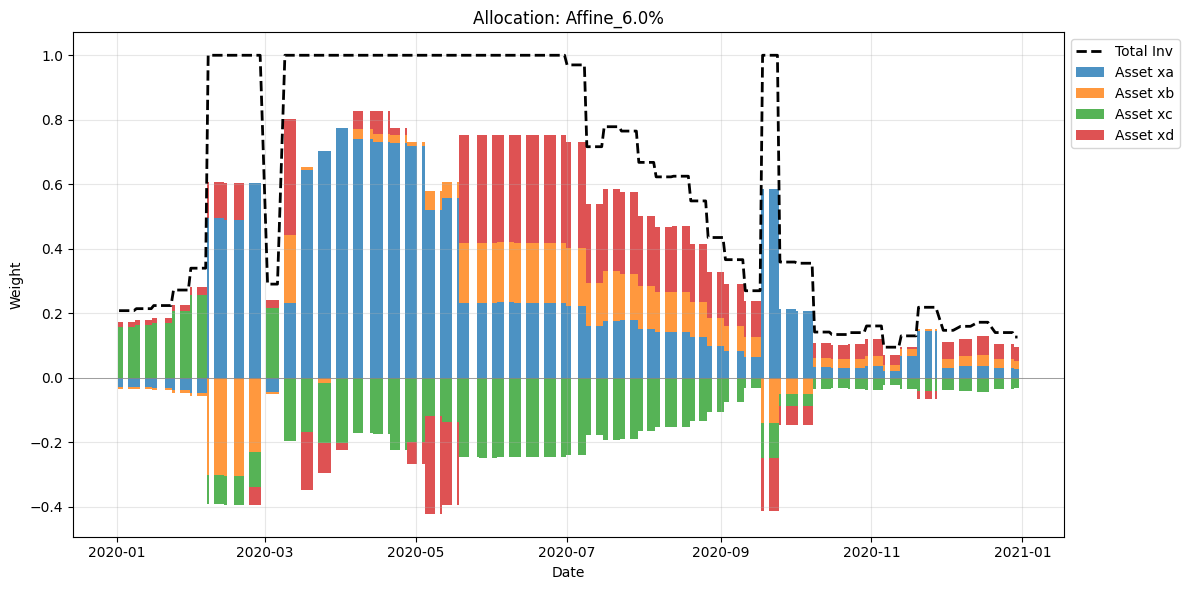

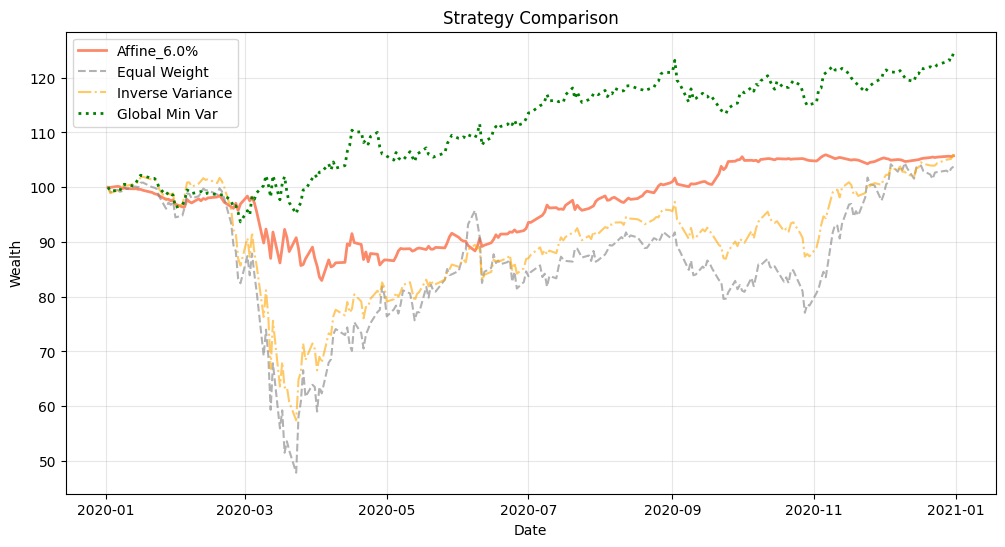

In [6]:
import torch
import numpy as np
import math


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BACKTEST_FILE = 'SP500_ETFs_data.csv' 
RF = 0.02
DT = 1/252
T_HORIZON = 1.0 

value_net = ValueNetwork(
    num_steps=int(T_HORIZON / DT),
    state_dim=5,
    hidden_layers=[64, 64] 
).to(torch.float64)

dummy_params = {
    'r': RF,
    'sigma_a': 0.0,
    'sigma_b': 0.0,
    'sigma_c': 0.0,
    'sigma_d': 0.0,
    'sigma_M': 0.0
}

ln_sre_eq_dummy = lnSRE_Equation(dummy_params, device=DEVICE)
solver = DBDPLnSRESolver(dummy_params, value_net, ln_sre_eq_dummy, device=DEVICE)

MODEL_PATH = './value_net_final_complete_set2.pt'
historical_params = solver.load_model(MODEL_PATH)

check_p0 = solver.P0.item()
p0_physical = math.exp(check_p0)  

print("-" * 50)
print(f'>>>  check_P(0) = {check_p0:.6f}')
print(f'>>>  P(0)        = {p0_physical:.6f}')
print("-" * 50)

ln_sre_eq_real = lnSRE_Equation(historical_params, device=DEVICE)
input_q0 = np.exp(-RF * T_HORIZON)


logspace_strategy = DBDP_Strategy_LogSpace(
    initial_check_p0=check_p0,     
    q0=input_q0,
    model_params=historical_params,
    r_f=RF,
    dt=DT,
    T_horizon=T_HORIZON,
    value_net=solver.value_net,    
    sre_eq=ln_sre_eq_real,        
    device=DEVICE,
)

bt_engine = BacktestEngine(assets=['xa', 'xb', 'xc', 'xd'])
bt_engine.load_data(BACKTEST_FILE)

targets = [0.06] 
 
results = bt_engine.run_backtest(
    strategy=logspace_strategy,   
    start_date='2020-01-01',
    end_date='2021-01-01',
    target_return=targets[0], 
    initial_capital=100.0, 
    strategy_window=20, 
    include_individual=False, 
    allow_leverage=False,
    rebalance_period=5
)


target_key = f'Affine_{targets[0]:.1%}'
bt_engine.plot_asset_allocation(target_key)

bt_engine.plot_comparison()

In [4]:
bt_engine.export_trades_to_csv('DBDP_trading_2020_6%.csv')


[Export]
 Interval : 2020-01-02 -> 2020-12-31
[Saved] DBDP_trading_2020_6%.csv
